**Dataset:** MSLR-WEB10K — Microsoft Learning to Rank  
**Source:** https://www.microsoft.com/en-us/research/project/mslr/  
**Format:** LibSVM — each row is `label qid:X feat1:val1 feat2:val2 ...`  
**Size:** ~1.2M query-document pairs | 10,000 queries | 136 features | Labels 0–4

In [42]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import scipy
import torch
import lightgbm as lgb
import warnings
from sklearn.datasets import load_svmlight_file

warnings.filterwarnings('ignore')

### Project Directory Setup

In [43]:
import os

# Defining project directory structure
dirs = [
    'data/raw',
    'data/processed',
    'models',
    'outputs/plots',
    'outputs/results',
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f"{d}")

print("\nDirectory structure ready")

data/raw
data/processed
models
outputs/plots
outputs/results

Directory structure ready


### Extracting Dataset

> We're using **Fold 1** only (train.txt, vali.txt, test.txt). The dataset has 5 folds for cross-validation — Fold 1 is the standard benchmark fold used in research papers. We've downlaoded the dataset manually from the source.

In [44]:
import zipfile

zip_path  = 'data/raw/MSLR-WEB10K.zip'
fold_path  = 'data/raw/Fold1'

if not os.path.exists(fold_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/raw/')
    print("Extraction complete")
else:
    print(f"Fold1 already extracted at {fold_path}")

# Verifying files
expected = ['train.txt','test.txt','vali.txt']
print("\nFile check:")
for f in expected:
    path = os.path.join(fold_path, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"{f:<12} {size_mb:.1f} MB")
    else:
        print(f"{f} not found")

Fold1 already extracted at data/raw/Fold1

File check:
train.txt    838.0 MB
test.txt     279.3 MB
vali.txt     272.8 MB


### LibSVM Parser

**LibSVM format:**
```
label qid:X 1:val 2:val 3:val ... 136:val
```
- `label` — relevance score (0, 1, 2, 3, 4)
- `qid` — query ID (groups documents belonging to the same query)
- `1:val ... 136:val` — feature index : feature value pairs

In [45]:
def parse_mslr(filepath):
    """
    Parsing an MSLR LibSVM file into a pandas DataFrame.
    
    Returns DataFrame with columns:
        label  : int (0-4 relevance label)
        qid    : int (query ID)
        f1-f136: float (feature values)
    """    
    X, y, qids = load_svmlight_file(
        filepath,
        query_id=True,
        n_features=136
    )
    
    # Converting sparse matrix to dense
    X_dense = X.toarray()
    
    # Creating DataFrame
    feat_cols = [f'f{i}' for i in range(1, 137)]
    df = pd.DataFrame(X_dense, columns=feat_cols)
    df.insert(0, 'label', y.astype(int))
    df.insert(1, 'qid',   qids.astype(int))
    
    print(f"Shape : {df.shape}")
    print(f"Queries : {df['qid'].nunique():,}")
    print(f"Label dist : {dict(df['label'].value_counts().sort_index())}")
    
    return df

print("Parser defined")

Parser defined


In [46]:
# Parsing all three splits
train_df = parse_mslr('data/raw/Fold1/train.txt')
print()
val_df   = parse_mslr('data/raw/Fold1/vali.txt')
print()
test_df  = parse_mslr('data/raw/Fold1/test.txt')

Shape : (723412, 138)
Queries : 6,000
Label dist : {0: np.int64(377957), 1: np.int64(232569), 2: np.int64(95082), 3: np.int64(12658), 4: np.int64(5146)}

Shape : (235259, 138)
Queries : 2,000
Label dist : {0: np.int64(121522), 1: np.int64(75815), 2: np.int64(31910), 3: np.int64(4209), 4: np.int64(1803)}

Shape : (241521, 138)
Queries : 2,000
Label dist : {0: np.int64(124784), 1: np.int64(77896), 2: np.int64(32459), 3: np.int64(4450), 4: np.int64(1932)}


### Sanity Checks and Visualizations

In [48]:
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    n_docs = len(df)
    n_queries = df['qid'].nunique()
    avg_docs  = n_docs / n_queries
    print(f"\n{name}")
    print(f"Documents  : {n_docs:>10,}")
    print(f"Queries    : {n_queries:>10,}")
    print(f"Avg docs/Queries : {avg_docs:>10.1f}")

print(f"\n{'Features':<20}: 136 (f1 - f136)")
print(f"{'Label range':<20}: {train_df['label'].min()} - {train_df['label'].max()}")
print(f"{'Missing values':<20}: {train_df.isnull().sum().sum()}")


Train
Documents  :    723,412
Queries    :      6,000
Avg docs/Queries :      120.6

Validation
Documents  :    235,259
Queries    :      2,000
Avg docs/Queries :      117.6

Test
Documents  :    241,521
Queries    :      2,000
Avg docs/Queries :      120.8

Features            : 136 (f1 - f136)
Label range         : 0 - 4
Missing values      : 0


### Visualizations

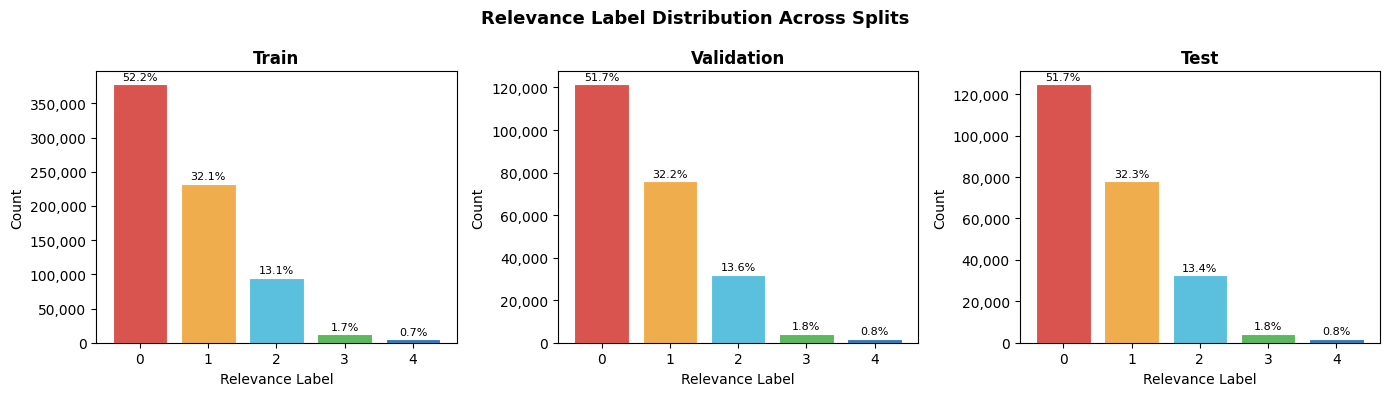

Saved to outputs/plots/label_distribution.png


In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Relevance Label Distribution Across Splits', fontsize=13, fontweight='bold')

colors_map = {0: '#D9534F', 1: '#F0AD4E', 2: '#5BC0DE', 3: '#5CB85C', 4: '#337AB7'}

for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[colors_map[i] for i in counts.index],
        edgecolor='white', linewidth=0.8
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Relevance Label')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    # Add percentage labels on bars
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.005,
            f'{val/total*100:.1f}%',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig('outputs/plots/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/plots/label_distribution.png")

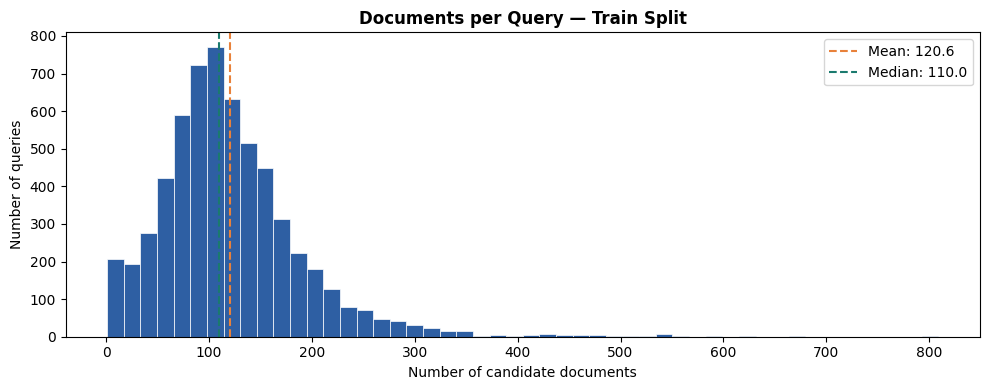

Min docs/query : 1
Max docs/query : 809
Mean docs/query: 120.6
Median: 110.0


In [50]:
# Docs per query distribution
docs_per_query = train_df.groupby('qid').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(docs_per_query, bins=50, color='#2E5FA3', edgecolor='white', linewidth=0.5)
ax.set_title('Documents per Query — Train Split', fontweight='bold')
ax.set_xlabel('Number of candidate documents')
ax.set_ylabel('Number of queries')
ax.axvline(docs_per_query.mean(), color='#E8813A', linestyle='--', linewidth=1.5,
           label=f'Mean: {docs_per_query.mean():.1f}')
ax.axvline(docs_per_query.median(), color='#1A7A6E', linestyle='--', linewidth=1.5,
           label=f'Median: {docs_per_query.median():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/docs_per_query.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min docs/query : {docs_per_query.min()}")
print(f"Max docs/query : {docs_per_query.max()}")
print(f"Mean docs/query: {docs_per_query.mean():.1f}")
print(f"Median: {docs_per_query.median():.1f}")

In [51]:
# Query difficulty check — queries with at least one relevant doc (label >= 1)
feat_cols = [f'f{i}' for i in range(1, 137)]

def query_difficulty(df):
    stats = df.groupby('qid')['label'].agg(
        max_label='max',
        n_relevant=lambda x: (x >= 1).sum(),
        n_highly_relevant=lambda x: (x >= 3).sum(),
        n_docs='count'
    )
    no_relevant = (stats['max_label'] == 0).sum()
    print(f"Queries with no relevant docs (label=0 only): {no_relevant} "
          f"({no_relevant/len(stats)*100:.1f}%)")
    print(f"Queries with highly relevant docs (label>=3): "
          f"{(stats['n_highly_relevant'] > 0).sum()} "
          f"({(stats['n_highly_relevant'] > 0).sum()/len(stats)*100:.1f}%)")
    return stats

print("Train:")
train_query_stats = query_difficulty(train_df)
print("Validation:")
val_query_stats = query_difficulty(val_df)
print("\nTest:")
test_query_stats  = query_difficulty(test_df)

Train:
Queries with no relevant docs (label=0 only): 182 (3.0%)
Queries with highly relevant docs (label>=3): 3774 (62.9%)
Validation:
Queries with no relevant docs (label=0 only): 61 (3.0%)
Queries with highly relevant docs (label>=3): 1306 (65.3%)

Test:
Queries with no relevant docs (label=0 only): 72 (3.6%)
Queries with highly relevant docs (label>=3): 1279 (63.9%)


In [57]:
# Basic feature statistics
feat_cols = [f'f{i}' for i in range(1, 137)]

feat_stats = train_df[feat_cols].describe().T
print("Features with zero variance (constant — safe to drop in feature engineering):")
zero_var = feat_stats[feat_stats['std'] == 0].index.tolist()
print(f"  {zero_var if zero_var else 'None found'}")

print(f"\nFeature value range:")
print(f"  Min overall : {train_df[feat_cols].min().min():.4f}")
print(f"  Max overall : {train_df[feat_cols].max().max():.4f}")
print(f"  Mean overall: {train_df[feat_cols].mean().mean():.4f}")

Features with zero variance (constant — safe to drop in feature engineering):
  None found

Feature value range:
  Min overall : -2083777989.0000
  Max overall : 980000001.0000
  Mean overall: 1244.0798


### Saving Processed Files

In [58]:
train_df.to_csv('data/processed/train.csv', index=False)
val_df.to_csv('data/processed/val.csv',     index=False)
test_df.to_csv('data/processed/test.csv',   index=False)

# Saving feature column list
with open('data/processed/feature_cols.txt', 'w') as f:
    f.write('\n'.join(feat_cols))

# Saving query difficulty stats
train_query_stats.to_csv('data/processed/train_query_stats.csv')
val_query_stats.to_csv('data/processed/val_query_stats.csv')
test_query_stats.to_csv('data/processed/test_query_stats.csv')

### Setup Summary

In [59]:
print(f"""
Dataset
  Train  : {len(train_df):>10,} rows | {train_df['qid'].nunique():,} queries
  Val    : {len(val_df):>10,} rows | {val_df['qid'].nunique():,} queries
  Test   : {len(test_df):>10,} rows | {test_df['qid'].nunique():,} queries
  Features: 136 (f1 - f136)
  Labels  : 0 (irrelevant) → 4 (perfectly relevant)

Next Step: EDA
""")


Dataset
  Train  :    723,412 rows | 6,000 queries
  Val    :    235,259 rows | 2,000 queries
  Test   :    241,521 rows | 2,000 queries
  Features: 136 (f1 - f136)
  Labels  : 0 (irrelevant) → 4 (perfectly relevant)

Next Step: EDA

